## **Environment Setup**
Mount Google Drive to access the dataset and store models/results.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Import Required Libraries**
Load essential Python libraries for data processing, visualization, and deep learning.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

## **Dataset Path Configuration**
Define the dataset directory containing the retinal images.

In [11]:
data_dir = "/content/drive/MyDrive/Retinopathy_Project/data/gaussian_filtered_images"

print("Dataset path:", data_dir)
print("Classes:", os.listdir(data_dir))

Dataset path: /content/drive/MyDrive/Retinopathy_Project/data/gaussian_filtered_images
Classes: ['export.pkl', 'Proliferate_DR', 'Mild', 'No_DR', 'Severe', 'Moderate']


## **Dataset Inspection**
Check the dataset structure and count the number of images in each class.

In [12]:
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)), "images")

Proliferate_DR : 295 images
Mild : 370 images
No_DR : 1805 images
Severe : 193 images
Moderate : 1009 images


## **Data Preprocessing and Image Generators**
Create training and validation data generators with image normalization.

In [13]:
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 2939 images belonging to 5 classes.
Found 733 images belonging to 5 classes.


## **Class Label Mapping**
Display how class labels are encoded for model training.

In [14]:
print(train_data.class_indices)

{'Mild': 0, 'Moderate': 1, 'No_DR': 2, 'Proliferate_DR': 3, 'Severe': 4}


## **Model 1** - **MobilenetV2**

### Build Model

In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load pretrained base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze backbone
for layer in base_model.layers:
    layer.trainable = False

# Add classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Train Model

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    ModelCheckpoint('/content/drive/MyDrive/Retinopathy_Project/models/best_mobilenetv2_gaussian.h5',
                    monitor='val_accuracy',
                    save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.3259 - loss: 1.7921

92/92 ━━━━━━━━━━━━━━━━━━━━ 1118s 12s/step - accuracy: 0.3270 - loss: 1.7895 - val_accuracy: 0.5771 - val_loss: 1.1609 - learning_rate: 1.0000e-04
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5851 - loss: 1.1836

92/92 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.5853 - loss: 1.1836 - val_accuracy: 0.6426 - val_loss: 1.0048 - learning_rate: 1.0000e-04
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6306 - loss: 1.0591

92/92 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.6307 - loss: 1.0589 - val_accuracy: 0.6726 - val_loss: 0.9202 - learning_rate: 1.0000e-04
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6661 - loss: 0.9742

92/92 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.6661 - loss: 0.9743 - val_accuracy: 0.6944 - val_loss: 0.8649 - learning_rate: 1.0000e-04
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6883 - loss: 0.9076

92/92 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.6882 - loss: 0.9078 - val_accuracy: 0.7149 - val_loss: 0.8260 - learning_rate: 1.0000e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6844 - loss: 0.9064

92/92 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.6845 - loss: 0.9062 - val_accuracy: 0.7326 - val_loss: 0.7968 - learning_rate: 1.0000e-04
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6792 - loss: 0.8932

92/92 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.6793 - loss: 0.8930 - val_accuracy: 0.7422 - val_loss: 0.7738 - learning_rate: 1.0000e-04
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.6909 - loss: 0.8746 - val_accuracy: 0.7422 - val_loss: 0.7576 - learning_rate: 1.0000e-04
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.6984 - loss: 0.8536 - val_accuracy: 0.7340 - val_loss: 0.7484 - learning_rate: 1.0000e-04
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.7160 - loss: 0.8165 - val_accuracy: 0.7381 - val_loss: 0.7320 - learning_rate: 1.0000e-04


In [17]:
print(os.listdir('/content/drive/MyDrive/Retinopathy_Project/models'))

['best_mobilenetv2_gaussian.h5']


### Training Results

In [30]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Mobilenet Training Accuracy:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Mobilenet Training Accuracy:
Training Accuracy: 0.7091
Validation Accuracy: 0.7381


### Classification Report

In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# True labels from validation generator
y_true = val_data.classes

# Predict probabilities
y_pred_prob = model.predict(val_data)

# Convert probabilities to predicted class index
y_pred = np.argmax(y_pred_prob, axis=1)

# Class names
labels = list(val_data.class_indices.keys())

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels))

23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step
Classification Report:

                precision    recall  f1-score   support

          Mild       0.06      0.03      0.04        74
      Moderate       0.28      0.44      0.34       201
         No_DR       0.49      0.52      0.50       361
Proliferate_DR       0.00      0.00      0.00        59
        Severe       0.00      0.00      0.00        38

      accuracy                           0.38       733
     macro avg       0.17      0.20      0.18       733
  weighted avg       0.32      0.38      0.35       733



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Confusion Matrix

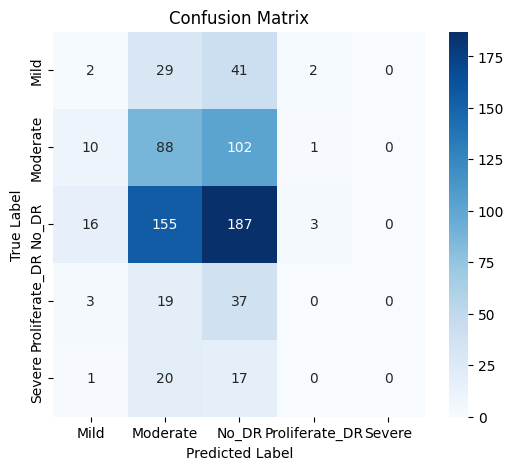

In [43]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("/content/drive/MyDrive/Retinopathy_Project/results/mobilenet_confusion_matrix.png")
plt.show()

### Sample Prediction

In [44]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Function to predict a retinal image
def predict_retina(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_index = np.argmax(pred)

    labels = list(val_data.class_indices.keys())
    label = labels[class_index]
    confidence = np.max(pred) * 100

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {label} ({confidence:.2f}%)")

    plt.savefig("/content/drive/MyDrive/Retinopathy_Project/results/sample_prediction.png")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


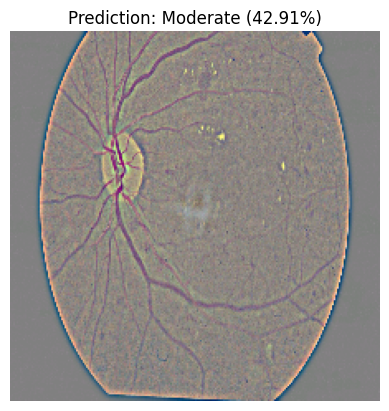

In [24]:
predict_retina("/content/drive/MyDrive/Retinopathy_Project/data/gaussian_filtered_images/Moderate/0ac436400db4.png")

## **Model 2** - **ResNet50**

### Build Model

In [26]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load pretrained base
base_model_resnet = ResNet50(weights='imagenet',
                             include_top=False,
                             input_shape=(224,224,3))

# Freeze backbone
for layer in base_model_resnet.layers:
    layer.trainable = False

# Custom classification head
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(train_data.num_classes, activation='softmax')(x)

model_resnet = Model(inputs=base_model_resnet.input, outputs=outputs)

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

###Train Model

In [27]:
history_resnet = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 753s 8s/step - accuracy: 0.1285 - loss: 2.1122 - val_accuracy: 0.4925 - val_loss: 1.3629 - learning_rate: 1.0000e-04
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 709s 8s/step - accuracy: 0.4096 - loss: 1.4386 - val_accuracy: 0.4925 - val_loss: 1.2626 - learning_rate: 1.0000e-04
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 711s 8s/step - accuracy: 0.4635 - loss: 1.3713 - val_accuracy: 0.4925 - val_loss: 1.2370 - learning_rate: 1.0000e-04
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 718s 8s/step - accuracy: 0.4774 - loss: 1.3164 - val_accuracy: 0.4925 - val_loss: 1.2167 - learning_rate: 1.0000e-04
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 710s 8s/step - accuracy: 0.5328 - loss: 1.2415 - val_accuracy: 0.4925 - val_loss: 1.1977 - learning_rate: 1.0000e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 714s 8s/step - accuracy: 0.5237 - loss: 1.2462 - val_accuracy: 0.4925 - val_loss: 1.1790 - learning_rate: 1.0000e-04


### Training Results

In [28]:
train_acc_resnet = history_resnet.history['accuracy'][-1]
val_acc_resnet = history_resnet.history['val_accuracy'][-1]

print("ResNet50 Performance:")
print(f"Training Accuracy: {train_acc_resnet:.4f}")
print(f"Validation Accuracy: {val_acc_resnet:.4f}")

ResNet50 Performance:
Training Accuracy: 0.5209
Validation Accuracy: 0.4925


In [45]:
model_resnet.save("/content/drive/MyDrive/Retinopathy_Project/models/resnet50_retinopathy.h5")

## **Model 3** - **EfficientNetB0**

### Build Model

In [31]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model_eff = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model_eff.layers:
    layer.trainable = False

x = base_model_eff.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(train_data.num_classes, activation='softmax')(x)

model_eff = Model(inputs=base_model_eff.input, outputs=outputs)

model_eff.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_eff.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

###Train Model

In [32]:
history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 374s 4s/step - accuracy: 0.3217 - loss: 1.5204 - val_accuracy: 0.4925 - val_loss: 1.2946 - learning_rate: 1.0000e-04
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 381s 4s/step - accuracy: 0.4912 - loss: 1.3100 - val_accuracy: 0.4925 - val_loss: 1.2925 - learning_rate: 1.0000e-04
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 304s 3s/step - accuracy: 0.4966 - loss: 1.3055 - val_accuracy: 0.4925 - val_loss: 1.2922 - learning_rate: 1.0000e-04
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.4975 - loss: 1.3070 - val_accuracy: 0.4925 - val_loss: 1.2921 - learning_rate: 1.0000e-04
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 313s 3s/step - accuracy: 0.4922 - loss: 1.3046 - val_accuracy: 0.4925 - val_loss: 1.2929 - learning_rate: 1.0000e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 304s 3s/step - accuracy: 0.4957 - loss: 1.3007 - val_accuracy: 0.4925 - val_loss: 1.2920 - learning_rate: 1.0000e-04


### Training Results

In [33]:
train_acc_eff = history_eff.history['accuracy'][-1]
val_acc_eff = history_eff.history['val_accuracy'][-1]

print("EfficientNetB0 Performance:")
print(f"Training Accuracy: {train_acc_eff:.4f}")
print(f"Validation Accuracy: {val_acc_eff:.4f}")

EfficientNetB0 Performance:
Training Accuracy: 0.4883
Validation Accuracy: 0.4925


In [46]:
model_eff.save("/content/drive/MyDrive/Retinopathy_Project/models/efficientnetb0_retinopathy.h5")

## **Model Comparison**

### Comparison Table

In [38]:
import pandas as pd

comparison = {
    "Model": ["MobileNetV2", "ResNet50", "EfficientNetB0"],
    "Training Accuracy": [train_acc, train_acc_resnet, train_acc_eff],
    "Validation Accuracy": [val_acc, val_acc_resnet, val_acc_eff]
}

comparison_df = pd.DataFrame(comparison)
comparison_df.to_csv(
    "/content/drive/MyDrive/Retinopathy_Project/results/model_comparison.csv",
    index=False
)

print("Final Model Comparison:")
display(comparison_df)

Final Model Comparison:


,Model,Training Accuracy,Validation Accuracy
0,MobileNetV2,0.709085,0.738063
1,ResNet50,0.520925,0.492497
2,EfficientNetB0,0.488261,0.492497


### Bar Chart Comparison

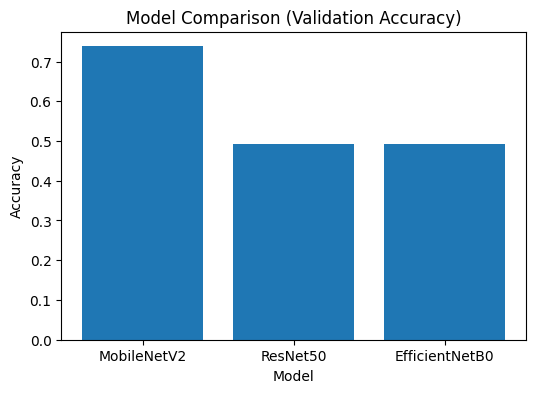

In [37]:
import matplotlib.pyplot as plt

models = ["MobileNetV2", "ResNet50", "EfficientNetB0"]
val_scores = [val_acc, val_acc_resnet, val_acc_eff]

plt.figure(figsize=(6,4))
plt.bar(models, val_scores)

plt.title("Model Comparison (Validation Accuracy)")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.savefig("/content/drive/MyDrive/Retinopathy_Project/results/model_comparison.png")
plt.show()

*MobileNetV2 achieved the highest validation accuracy among the evaluated models.
The lighter architecture appears to generalize better on this dataset compared
to deeper models such as ResNet50 and EfficientNetB0.*

## **Conclusion**



This project explored deep learning approaches for detecting diabetic retinopathy from retinal fundus images using transfer learning.

Three pretrained CNN architectures were evaluated:
- MobileNetV2
- ResNet50
- EfficientNetB0

Among the models tested, **MobileNetV2** achieved the best performance with a **validation accuracy of 73.8%**. The lighter architecture likely generalizes better on this relatively small dataset.

ResNet50 and EfficientNetB0 showed lower performance under the current training setup, likely due to fully frozen feature extractors and limited training epochs.

Future improvements could include:
- fine-tuning deeper layers
- class balancing techniques
- training with larger datasets
- experimenting with additional architectures.